MSE: 5.646125047196561
R²: 0.5589300404379556


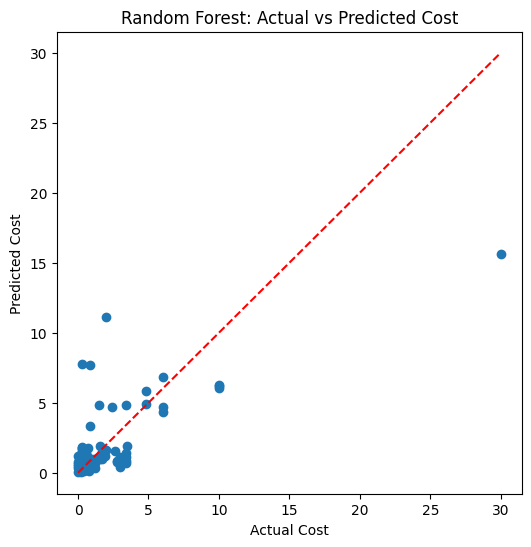

Test size: 95


In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("llmdata.csv")

cols = [
    "arena_votes",
    "composite_benchmark",
    "aa_coding_index",
    "scicode",
    "chatbot_arena_elo",
    #"mmlu_pro",
    #"gpqa_diamond",
    #"time_to_first_token_s",
    #"math_500",
    "output_tokens_per_second",
    "is_open_source",
    "release_year",
    "parameter_count",
]

target = "blended_cost_usd_per_1m"

df_clean = df[cols + [target]].dropna(subset=[target])

X = df_clean[cols].copy()
y = np.log1p(df_clean[target].copy())

X["is_open_source"] = X["is_open_source"].astype(int)

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.3, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_pred_real = np.expm1(y_pred)
y_test_real = np.expm1(y_test)

mse = mean_squared_error(y_test_real, y_pred_real)
r2 = r2_score(y_test_real, y_pred_real)

print("MSE:", mse)
print("R²:", r2)

plt.figure(figsize=(6,6))
plt.scatter(y_test_real, y_pred_real)

plt.xlabel("Actual Cost")
plt.ylabel("Predicted Cost")
plt.title("Random Forest: Actual vs Predicted Cost")

min_v = min(y_test_real.min(), y_pred_real.min())
max_v = max(y_test_real.max(), y_pred_real.max())

plt.plot([min_v, max_v], [min_v, max_v], 'r--')
plt.show()

print("Test size:", len(y_test))